In [3]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install ydata-profiling xgboost shap --quiet

# 🌾 Agriculture: Crop Yield Driver Discovery
### Using Feature Selection + XGBoost + Explainable AI (SHAP)

## 📌 Topic
**Agriculture: Crop Yield Driver Discovery using Feature Selection + XGBoost.**

## 🎯 Aim
Identify the top factors that drive crop yield and find the best predictive model through systematic model selection and evaluation.

## 📖 Introduction
Agriculture is vital for food security and economies worldwide. Crop yield varies due to factors like rainfall, temperature, soil type, irrigation, fertilizer usage, pests, and farming practices. Accurate yield prediction is crucial for farmers, supply chains, and policymakers.

This project develops a machine learning system — primarily using **XGBoost** — for crop yield prediction. Crucially, it also identifies the most influential **Crop Yield Drivers** using multiple feature selection techniques and explains predictions using **SHAP** (SHapley Additive exPlanations).

---
## STEP 1: Import Libraries & Load Data

In [4]:
# ============================================================
# IMPORTS
# ============================================================
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression, f_regression, RFE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
import shap
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# ============================================================
# LOAD DATASET  (place crop_yield.csv in the same folder)
# ============================================================

DATA_PATH = "crop_yield.csv"
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 1,000,000 rows × 10 columns


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


---
## STEP 2: Exploratory Data Analysis (EDA)

In [7]:
# ============================================================
# BASIC INFO
# ============================================================
print("Shape         :", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape         : (1000000, 10)

Data Types:
Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

Missing Values:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Basic Statistics:


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


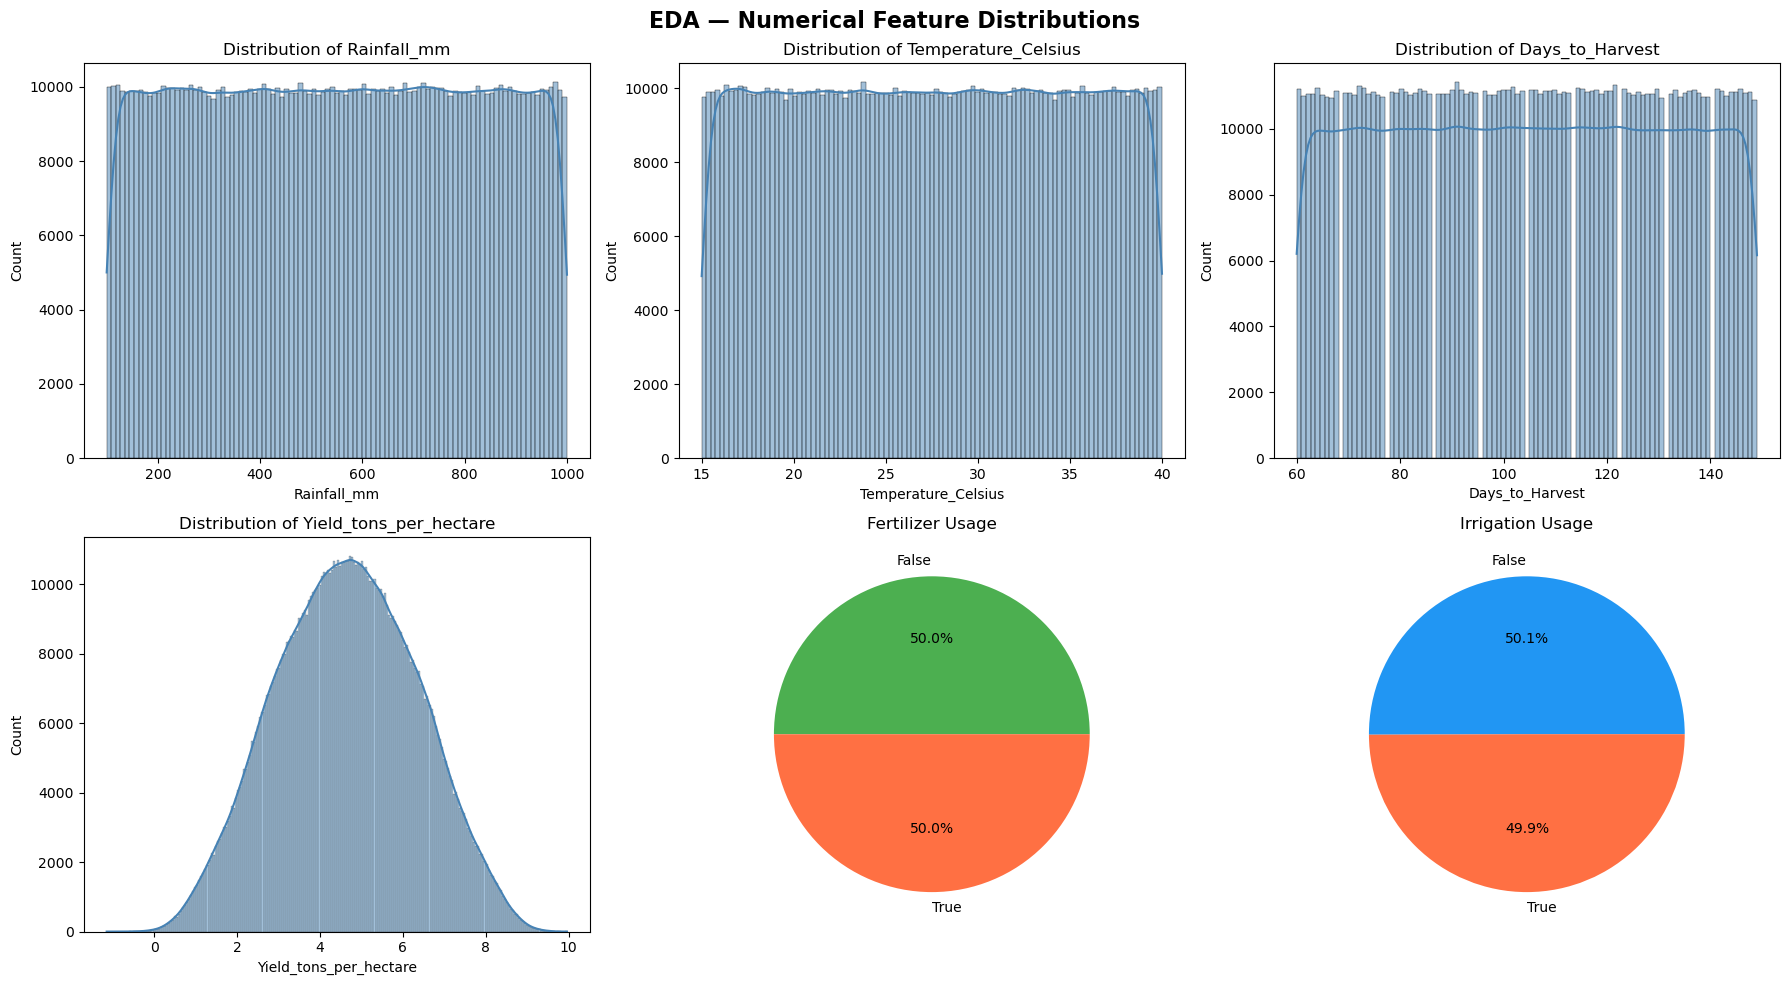

In [8]:
# ============================================================
# EDA VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Numerical Feature Distributions", fontsize=16, fontweight='bold')

num_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

# Fertilizer & Irrigation usage
axes[1][1].pie(
    df["Fertilizer_Used"].value_counts(),
    labels=df["Fertilizer_Used"].value_counts().index,
    autopct='%1.1f%%', colors=['#4CAF50','#FF7043']
)
axes[1][1].set_title("Fertilizer Usage")

axes[1][2].pie(
    df["Irrigation_Used"].value_counts(),
    labels=df["Irrigation_Used"].value_counts().index,
    autopct='%1.1f%%', colors=['#2196F3','#FF7043']
)
axes[1][2].set_title("Irrigation Usage")

plt.tight_layout()
plt.show()

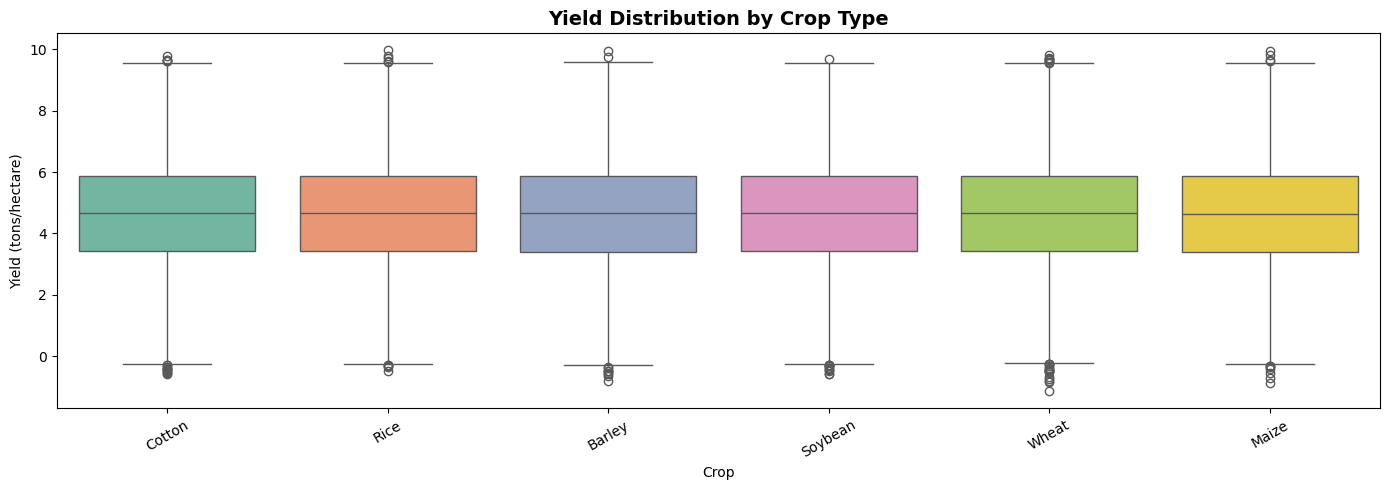

In [9]:
# ============================================================
# YIELD BY CROP TYPE — Boxplot
# ============================================================
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="Crop", y="Yield_tons_per_hectare", palette="Set2")
plt.title("Yield Distribution by Crop Type", fontsize=14, fontweight='bold')
plt.xlabel("Crop")
plt.ylabel("Yield (tons/hectare)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

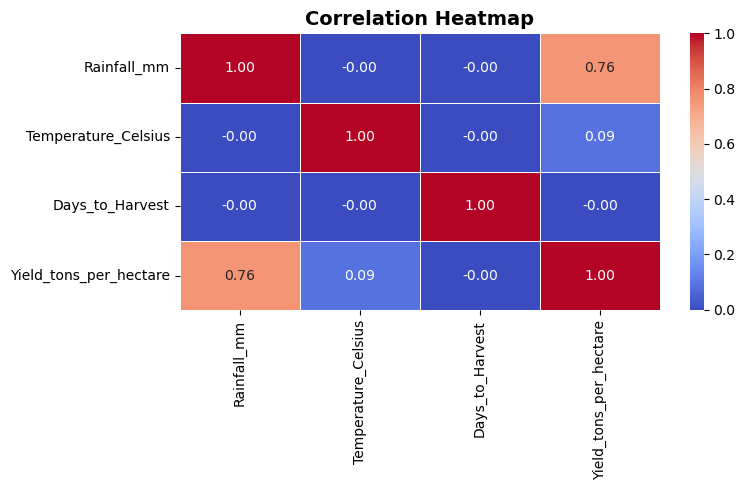

In [10]:
# ============================================================
# CORRELATION HEATMAP (numerical features)
# ============================================================
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 5))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# AUTOMATED PROFILING REPORT 
# ============================================================
profile = ProfileReport(df, title="Crop Yield EDA Report", minimal=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/16 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 17.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

---
## STEP 3: Feature Engineering

In [12]:
# ============================================================
# CLIMATE INTERACTION FEATURES
# ============================================================

# Rainfall × Temperature index
df["Rainfall_Temp_Index"] = df["Rainfall_mm"] * df["Temperature_Celsius"]

# Effective Water Availability (rainfall + irrigation bonus)
df["Water_Availability"] = df["Rainfall_mm"] + np.where(
    df["Irrigation_Used"] == "Yes", 500, 0
)

print("✅ Climate interaction features created.")

✅ Climate interaction features created.


In [13]:
# ============================================================
# BINARY CONVERSIONS  (Yes/No → 1/0)
# ============================================================

df["Has_Fertilizer"] = (df["Fertilizer_Used"] == "Yes").astype(int)
df["Has_Irrigation"] = (df["Irrigation_Used"] == "Yes").astype(int)

print("Has_Fertilizer unique:", df["Has_Fertilizer"].unique())
print("Has_Irrigation unique:", df["Has_Irrigation"].unique())
print("Nulls:\n", df[["Has_Fertilizer", "Has_Irrigation"]].isnull().sum())

Has_Fertilizer unique: [0]
Has_Irrigation unique: [0]
Nulls:
 Has_Fertilizer    0
Has_Irrigation    0
dtype: int64


In [14]:
# ============================================================
# CATEGORICAL GROUPINGS
# ============================================================

CROP_MAP = {
    "Rice": "Cereal", "Wheat": "Cereal", "Barley": "Cereal",
    "Cotton": "Cash_Crop", "Sugarcane": "Cash_Crop",
    "Lentils": "Pulse", "Chickpeas": "Pulse",
    "Soybean": "Oilseed", "Mustard": "Oilseed"
}
df["Crop_Category"] = df["Crop"].map(CROP_MAP).fillna("Other")

def rainfall_category(rain):
    if rain < 500:
        return "Low"
    elif rain <= 1000:
        return "Medium"
    return "High"

df["Rainfall_Category"] = df["Rainfall_mm"].apply(rainfall_category)

print("Crop categories:", df["Crop_Category"].value_counts().to_dict())
print("Rainfall categories:", df["Rainfall_Category"].value_counts().to_dict())

Crop categories: {'Cereal': 500242, 'Other': 166824, 'Cash_Crop': 166585, 'Oilseed': 166349}
Rainfall categories: {'Medium': 555721, 'Low': 444279}


---
## STEP 4: Train-Test Split & Target Encoding

In [15]:
# ============================================================
# SPLIT FIRST — prevents data leakage in target encoding
# ============================================================
X = df.drop("Yield_tons_per_hectare", axis=1)
y = df["Yield_tons_per_hectare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (800000, 15)  |  Test: (200000, 15)


In [16]:
# ============================================================
# TARGET ENCODING  (computed on train only → mapped to test)
# ============================================================
train_data = X_train.copy()
train_data["Yield_tons_per_hectare"] = y_train

crop_mean   = train_data.groupby("Crop")["Yield_tons_per_hectare"].mean()
soil_mean   = train_data.groupby("Soil_Type")["Yield_tons_per_hectare"].mean()
region_mean = train_data.groupby("Region")["Yield_tons_per_hectare"].mean()

for dataset in [X_train, X_test]:
    dataset["Crop_Mean_Yield"]   = dataset["Crop"].map(crop_mean)
    dataset["Soil_Mean_Yield"]   = dataset["Soil_Type"].map(soil_mean)
    dataset["Region_Mean_Yield"] = dataset["Region"].map(region_mean)

# Fill any unseen categories in test with train mean
X_test.fillna(X_train.mean(numeric_only=True), inplace=True)

print("Remaining nulls in train:", X_train.isnull().sum().sum())
print("Remaining nulls in test :", X_test.isnull().sum().sum())

Remaining nulls in train: 0
Remaining nulls in test : 0


In [17]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================
CAT_COLS = ["Region", "Soil_Type", "Crop", "Weather_Condition", "Crop_Category", "Rainfall_Category"]

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)

# Align columns — fill any missing test columns with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

print(f"Train shape after encoding: {X_train.shape}")
print(f"Test  shape after encoding: {X_test.shape}")

Train shape after encoding: (800000, 31)
Test  shape after encoding: (200000, 31)


---
## STEP 5: Feature Selection

In [18]:
# ============================================================
# 1. PEARSON CORRELATION
# ============================================================
correlation    = pd.concat([X_train, y_train], axis=1).corr()
corr_target    = correlation["Yield_tons_per_hectare"].drop("Yield_tons_per_hectare")
corr_selected  = corr_target[abs(corr_target) > 0.1].index.tolist()
print(f"Correlation selected  : {len(corr_selected)} features")

Correlation selected  : 6 features


In [19]:
# ============================================================
# 2. ANOVA F-TEST
# ============================================================
f_scores, _  = f_regression(X_train, y_train)
f_series     = pd.Series(f_scores, index=X_train.columns)
f_selected   = f_series.sort_values(ascending=False).head(int(0.25 * len(f_series))).index.tolist()
print(f"F-test selected       : {len(f_selected)} features")

F-test selected       : 7 features


In [20]:
# ============================================================
# 3. RECURSIVE FEATURE ELIMINATION (RFE) with Random Forest
# ============================================================
rf_rfe    = RandomForestRegressor(n_estimators=20, random_state=RANDOM_STATE)
X_sample  = X_train.sample(30000, random_state=RANDOM_STATE)
y_sample  = y_train.loc[X_sample.index]

rfe       = RFE(estimator=rf_rfe, n_features_to_select=15, step=3)
rfe.fit(X_sample, y_sample)
rfe_selected = X_sample.columns[rfe.get_support()].tolist()
print(f"RFE selected          : {len(rfe_selected)} features")

RFE selected          : 15 features


In [21]:
# ============================================================
# 4. XGBOOST FEATURE IMPORTANCE
# ============================================================
xgb_fs  = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)
xgb_fs.fit(X_train, y_train)

xgb_importance = pd.Series(xgb_fs.feature_importances_, index=X_train.columns)
xgb_selected   = xgb_importance.sort_values(ascending=False).head(int(0.25 * len(xgb_importance))).index.tolist()
print(f"XGB importance selected: {len(xgb_selected)} features")

XGB importance selected: 7 features


In [22]:
# ============================================================
# 5. LASSO (L1 Regularization)
# ============================================================
lasso         = Lasso(alpha=0.01, random_state=RANDOM_STATE)
lasso.fit(X_train, y_train)
lasso_selected = X_train.columns[lasso.coef_ != 0].tolist()
print(f"Lasso selected        : {len(lasso_selected)} features")

Lasso selected        : 7 features


In [23]:
# ============================================================
# 6. MUTUAL INFORMATION
# ============================================================
X_mi_sample = X_train.sample(30000, random_state=RANDOM_STATE)
y_mi_sample = y_train.loc[X_mi_sample.index]

mi           = mutual_info_regression(X_mi_sample, y_mi_sample, random_state=RANDOM_STATE)
mi_series    = pd.Series(mi, index=X_mi_sample.columns)
mi_selected  = mi_series.sort_values(ascending=False).head(int(0.25 * len(mi_series))).index.tolist()
print(f"Mutual Info selected  : {len(mi_selected)} features")

Mutual Info selected  : 7 features


In [24]:
# ============================================================
# VOTING — keep features selected by ≥ 4 methods
# ============================================================
methods = {
    "Correlation" : corr_selected,
    "Mutual_Info" : mi_selected,
    "F_test"      : f_selected,
    "Lasso"       : lasso_selected,
    "RFE_RF"      : rfe_selected,
    "XGBoost"     : xgb_selected
}

feature_scores = pd.DataFrame(index=X_train.columns)
for method, selected in methods.items():
    feature_scores[method] = feature_scores.index.isin(selected)

feature_scores["Vote_Count"] = feature_scores.sum(axis=1)
feature_scores = feature_scores.sort_values("Vote_Count", ascending=False)

VOTE_THRESHOLD = 4
final_features = feature_scores[feature_scores["Vote_Count"] >= VOTE_THRESHOLD].index.tolist()

X_train_final = X_train[final_features]
X_test_final  = X_test[final_features]

print(f"Final selected features (vote ≥ {VOTE_THRESHOLD}): {len(final_features)}")
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)
feature_scores.head(15)

Final selected features (vote ≥ 4): 6
X_train_final: (800000, 6)
X_test_final : (200000, 6)


,Correlation,Mutual_Info,F_test,Lasso,RFE_RF,XGBoost,Vote_Count
Rainfall_mm,True,True,True,True,True,True,6
Fertilizer_Used,True,True,True,True,True,True,6
Irrigation_Used,True,True,True,True,True,True,6
Rainfall_Temp_Index,True,True,True,True,True,True,6
Temperature_Celsius,False,True,True,True,True,True,5
Water_Availability,True,True,True,True,True,False,5
Rainfall_Category_Medium,True,True,True,False,False,False,3
Days_to_Harvest,False,False,False,True,True,False,2
Soil_Mean_Yield,False,False,False,False,True,False,1
Region_South,False,False,False,False,False,True,1


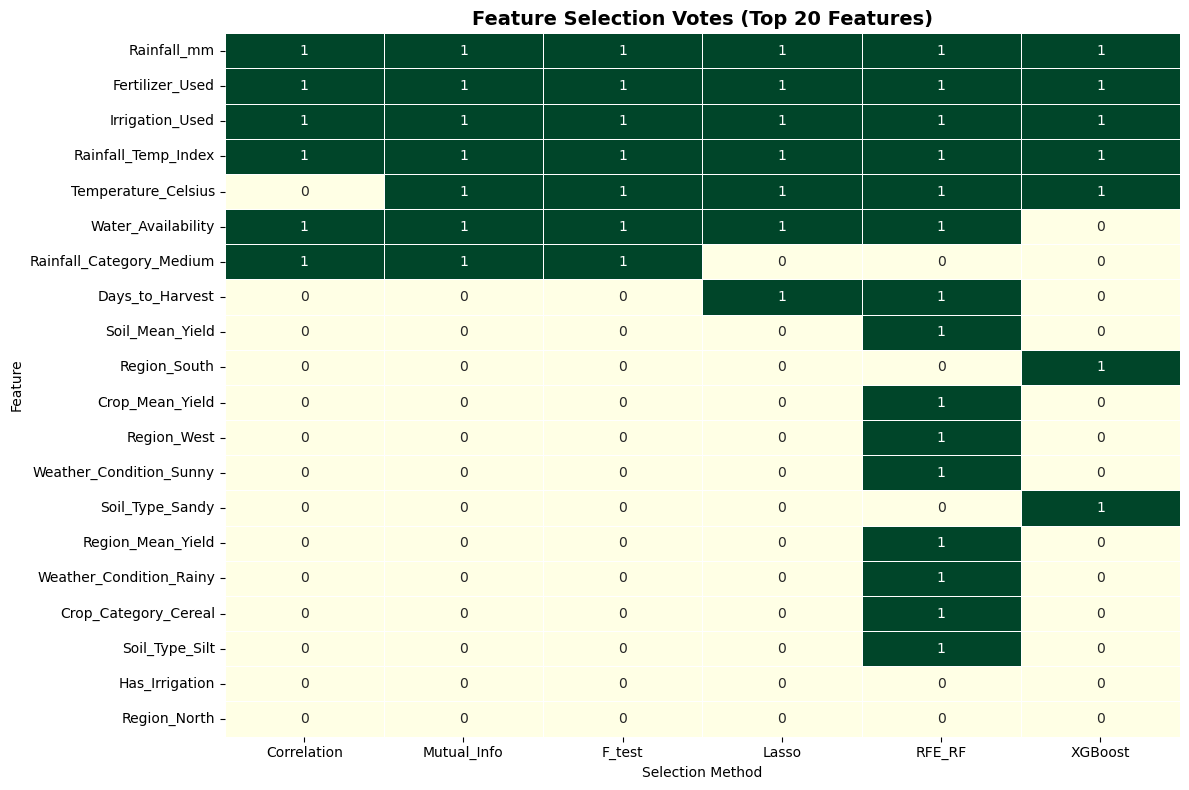

In [25]:
# ============================================================
# FEATURE SELECTION VOTE HEATMAP
# ============================================================
top_features_viz = feature_scores.head(20)
vote_matrix = top_features_viz[list(methods.keys())].astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(vote_matrix, annot=True, cmap="YlGn", linewidths=0.5, cbar=False,
            yticklabels=vote_matrix.index)
plt.title("Feature Selection Votes (Top 20 Features)", fontsize=14, fontweight='bold')
plt.xlabel("Selection Method")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## STEP 6: Model Training & Selection

In [26]:
# ============================================================
# HELPER — compute all metrics at once
# ============================================================
def evaluate_model(name, y_true, y_pred, elapsed):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100   # fixed: ×100 not ×110
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  Time : {elapsed:.2f}s")
    return {"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape, "Time(s)": elapsed}

results = []

In [27]:
# ============================================================
# MODEL 1 — Linear Regression
# ============================================================
t0  = time.time()
lr  = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred_lr = lr.predict(X_test_final)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr, time.time() - t0))


 Linear Regression
  R²   : 0.9130
  RMSE : 0.5008
  MAE  : 0.3996
  MAPE : 12.65%
  Time : 0.29s


In [28]:
# ============================================================
# MODEL 2 — Random Forest
# ============================================================
t0 = time.time()
rf = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, time.time() - t0))


 Random Forest
  R²   : 0.9125
  RMSE : 0.5021
  MAE  : 0.4006
  MAPE : 12.69%
  Time : 46.59s


In [29]:
# ============================================================
# MODEL 3 — Linear SVR (via Pipeline for proper scaling)
# ============================================================
t0 = time.time()
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', LinearSVR(C=1.0, epsilon=0.1, max_iter=5000, random_state=RANDOM_STATE))
])
svr_pipeline.fit(X_train_final, y_train)
y_pred_svr = svr_pipeline.predict(X_test_final)
results.append(evaluate_model("Linear SVR", y_test, y_pred_svr, time.time() - t0))


 Linear SVR
  R²   : 0.9130
  RMSE : 0.5008
  MAE  : 0.3996
  MAPE : 12.63%
  Time : 49.22s


In [30]:
# ============================================================
# MODEL 4 — XGBoost (Tuned with RandomizedSearchCV)
# ============================================================
param_dist = {
    "n_estimators"    : [200, 300, 400],
    "learning_rate"   : [0.03, 0.05, 0.1],
    "max_depth"       : [4, 6, 8],
    "subsample"       : [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha"       : [0.0, 0.1, 0.5],
    "reg_lambda"      : [0.5, 1.0, 2.0]
}

xgb_base = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
xgb_search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=20, cv=3,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_final, y_train)
xgb = xgb_search.best_estimator_

y_pred_xgb = xgb.predict(X_test_final)
results.append(evaluate_model("XGBoost (Tuned) ⭐", y_test, y_pred_xgb, time.time() - t0))

print("\nBest Params:", xgb_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 XGBoost (Tuned) ⭐
  R²   : 0.9129
  RMSE : 0.5011
  MAE  : 0.3998
  MAPE : 12.68%
  Time : 939.95s

Best Params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


In [31]:
# ============================================================
# CROSS-VALIDATION SCORE (XGBoost)
# ============================================================
cv_scores = cross_val_score(xgb, X_train_final, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"XGBoost CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

XGBoost CV R² (5-fold): 0.9129 ± 0.0005


In [32]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
results_df.style.highlight_max(subset=["R2"], color='lightgreen') \
                .highlight_min(subset=["RMSE", "MAE", "MAPE"], color='lightgreen')

,R2,RMSE,MAE,MAPE,Time(s)
Model,,,,,
Linear Regression,0.913015,0.500773,0.399551,12.647786,0.292007
Random Forest,0.912540,0.502137,0.400629,12.690721,46.587345
Linear SVR,0.913011,0.500784,0.399558,12.625327,49.224323
XGBoost (Tuned) ⭐,0.912906,0.501086,0.399801,12.684950,939.951725


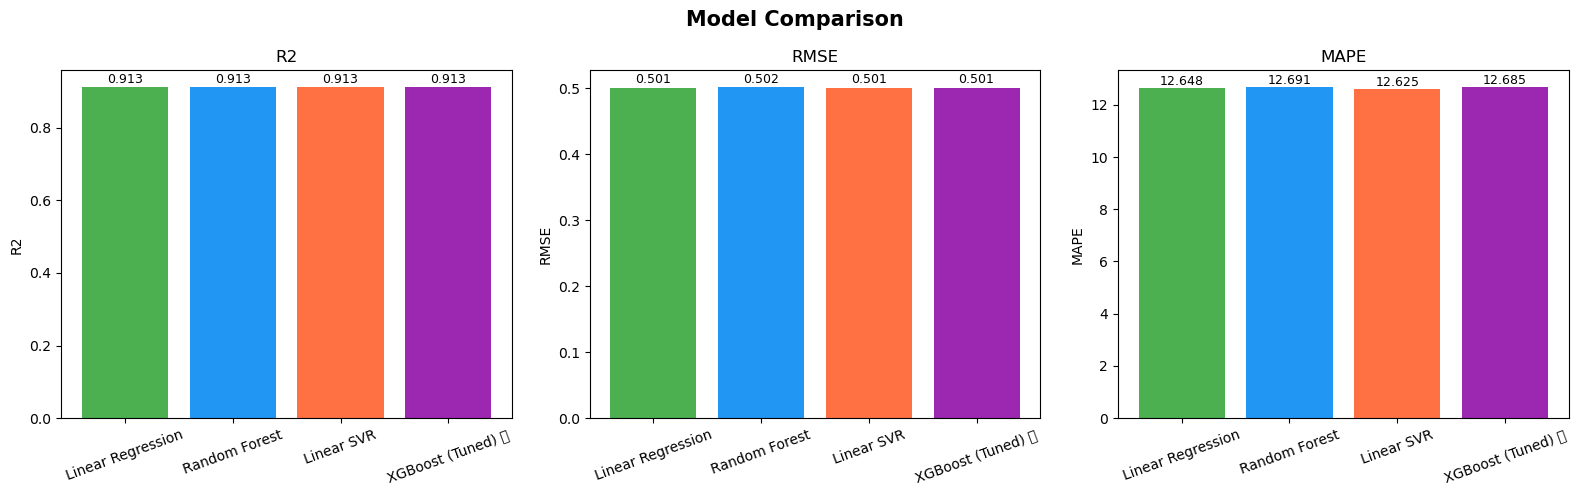

In [33]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison", fontsize=15, fontweight='bold')

metrics   = ["R2", "RMSE", "MAPE"]
colors    = ["#4CAF50", "#2196F3", "#FF7043", "#9C27B0"]
labels    = results_df.index.tolist()

for i, metric in enumerate(metrics):
    axes[i].bar(labels, results_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(axes[i].patches, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## STEP 7: Save the Best Model

In [34]:
# ============================================================
# SAVE MODEL  (so you don't need to retrain every time)
# ============================================================
MODEL_PATH = "xgboost_crop_yield_model.pkl"
joblib.dump(xgb, MODEL_PATH)
print(f"✅ Model saved to '{MODEL_PATH}'")

# To reload later:
# xgb_loaded = joblib.load(MODEL_PATH)

✅ Model saved to 'xgboost_crop_yield_model.pkl'


---
## STEP 8: Model Interpretation (SHAP Analysis)

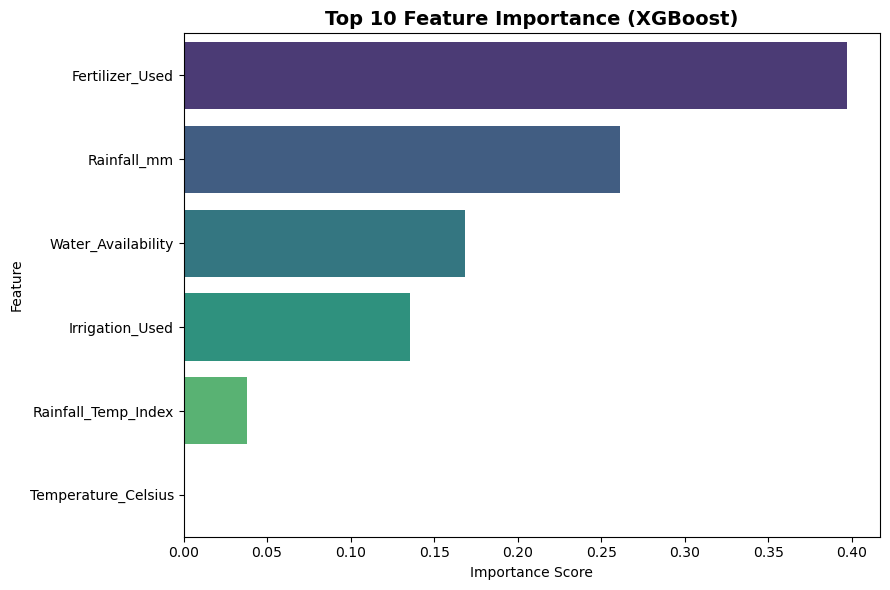

In [35]:
# ============================================================
# TOP 10 FEATURE IMPORTANCE (XGBoost built-in)
# ============================================================
importances       = xgb.feature_importances_
feature_importance = pd.DataFrame({
    "Feature"   : X_train_final.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top10 = feature_importance.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=top10, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importance (XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

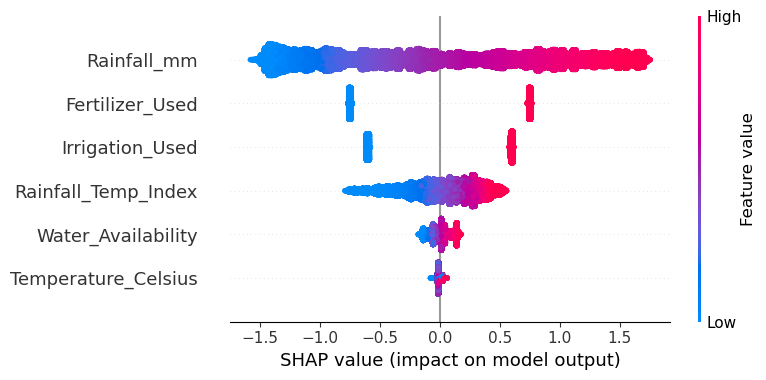

In [36]:
# ============================================================
# SHAP — Global Summary Plot
# ============================================================
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_final)

plt.figure()
shap.summary_plot(shap_values, X_test_final)

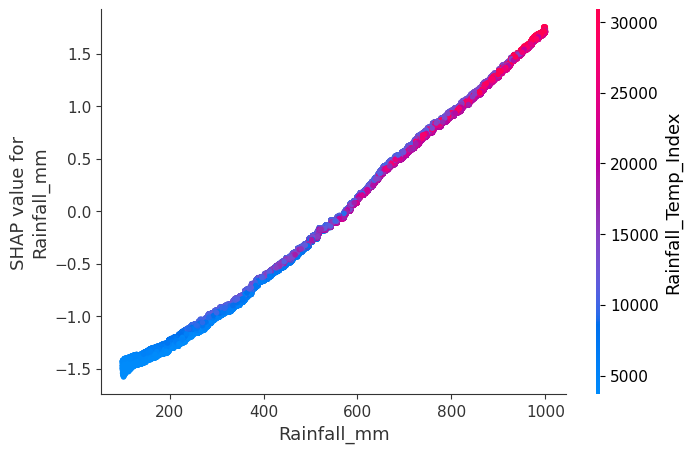

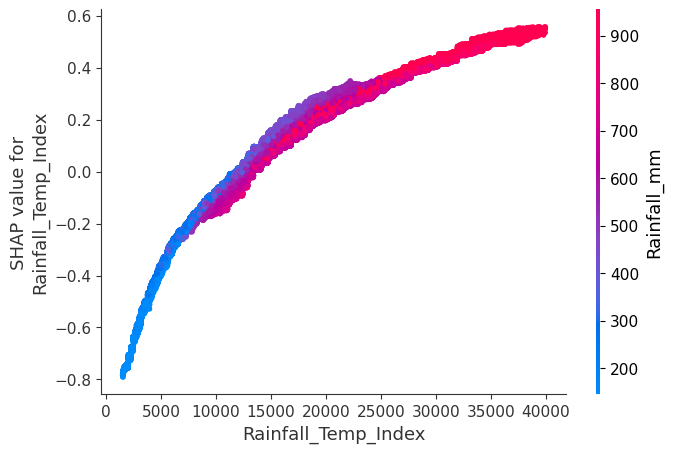

In [37]:
# ============================================================
# SHAP — Dependence Plots (key drivers)
# ============================================================
shap.dependence_plot("Rainfall_mm", shap_values, X_test_final)
shap.dependence_plot("Rainfall_Temp_Index", shap_values, X_test_final)

---
## STEP 9: Error Analysis

In [38]:
# ============================================================
# ERROR ANALYSIS BY REGION
# ============================================================
error_df = pd.DataFrame({
    "Region"         : df.loc[y_test.index, "Region"],
    "Crop"           : df.loc[y_test.index, "Crop"],
    "Actual_Yield"   : y_test.values,
    "Predicted_Yield": y_pred_xgb
})
error_df["Absolute_Error"] = abs(error_df["Actual_Yield"] - error_df["Predicted_Yield"])
error_df["APE"]             = (error_df["Absolute_Error"] / error_df["Actual_Yield"]) * 100

region_error = error_df.groupby("Region").agg(
    Mean_AE  = ("Absolute_Error", "mean"),
    Mean_APE = ("APE",            "mean")
).sort_values("Mean_AE", ascending=False)

crop_error = error_df.groupby("Crop").agg(
    Mean_AE  = ("Absolute_Error", "mean"),
    Mean_APE = ("APE",            "mean")
).sort_values("Mean_AE", ascending=False)

print("Error by Region:\n", region_error)
print("\nError by Crop:\n",   crop_error)

Error by Region:
          Mean_AE   Mean_APE
Region                     
North   0.403148  11.610457
South   0.399812  10.487642
West    0.398334  11.829447
East    0.397909  11.066859

Error by Crop:
           Mean_AE   Mean_APE
Crop                        
Wheat    0.401589  11.431415
Soybean  0.400681  11.146375
Maize    0.399379  11.282141
Barley   0.399287  11.058088
Cotton   0.399064  10.764118
Rice     0.398816  11.808632


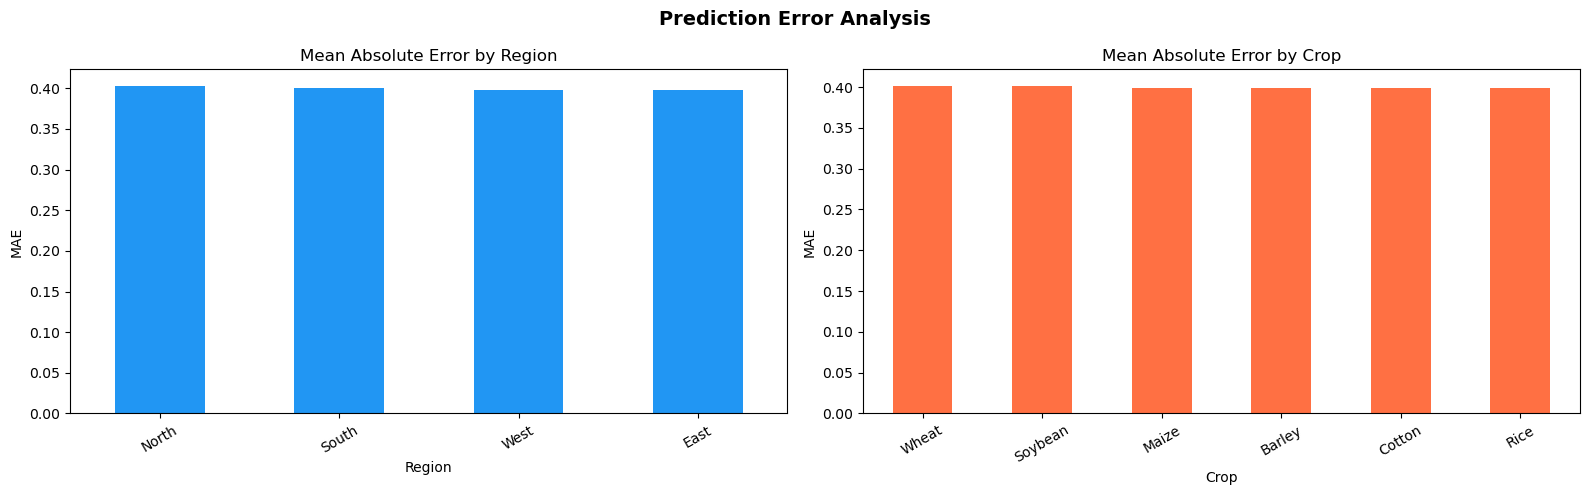

In [39]:
# ============================================================
# ERROR CHARTS — Region & Crop side by side
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Prediction Error Analysis", fontsize=14, fontweight='bold')

region_error["Mean_AE"].plot(kind="bar", ax=axes[0], color="#2196F3")
axes[0].set_title("Mean Absolute Error by Region")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=30)

crop_error["Mean_AE"].plot(kind="bar", ax=axes[1], color="#FF7043")
axes[1].set_title("Mean Absolute Error by Crop")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

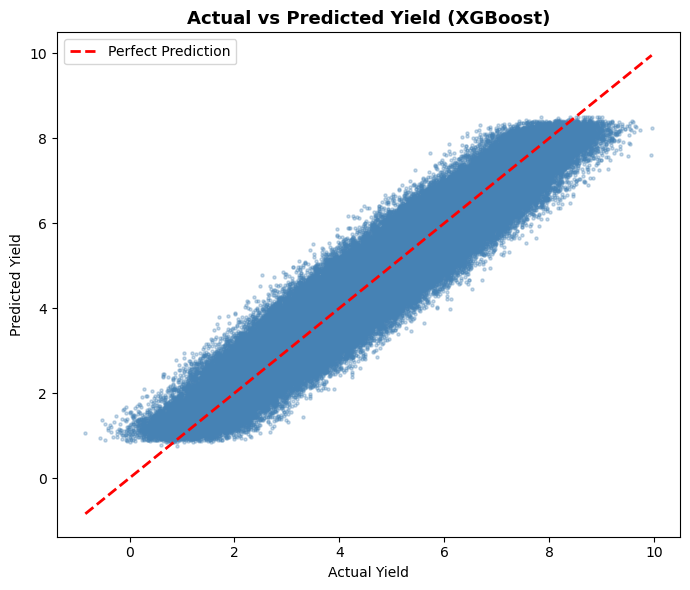

In [40]:
# ============================================================
# ACTUAL vs PREDICTED SCATTER
# ============================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (XGBoost)", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 📚 References
1. Ravi, R. et al. — *Crop Yield Prediction using XGBoost Algorithm.* ResearchGate, 2022. https://www.researchgate.net/publication/364028532
2. Shahhosseini, M. et al. — *Forecasting corn yield with machine learning ensembles.* Frontiers in Plant Science, 2020. https://www.sciencedirect.com/science/article/abs/pii/S0168169922006548
3. van Klompenburg, T. et al. — *Crop yield prediction using machine learning: A systematic literature review.* Computers and Electronics in Agriculture, 2020. https://www.sciencedirect.com/science/article/pii/S0168169920302301
4. You, J. et al. — *Deep Gaussian Process for Crop Yield Prediction.* arXiv, 2017. https://arxiv.org/pdf/2008.04060
5. Crane-Droesch, A. — *Machine learning methods for crop yield prediction.* PLOS ONE, 2018. https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0156571
6. Dataset: Samuel Oti Attakorah — *Agriculture Crop Yield Dataset.* Kaggle. https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield